<a href="https://colab.research.google.com/github/Dawitay/Deep-Learning-Final-Project-Comparing-VGG-Style-and-MobileNetV2-Style-CNN-Architectures/blob/main/DL_Assignment_II_Dawit_Ayele.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Name: **Dawit Ayele**  |  ID: GSR0350/18


**ASSIGNMENT II**

1. Implement and train at least two distinct CNN architectures (e.g., a custom 3-layer VGG-
style model, a lightweight MobileNetV2-style model) on the CIFAR-10 dataset.

2. Compare their performance not only on accuracy but also on computational efficiency
(e.g., training/inference time, number of parameters, FLOPs using thop library).
3. Analyze the trade-offs between model complexity, speed, and accuracy.
4. In your report, propose a research direction for designing more efficient architectures for
resource-constrained environments.
5. Note: CIFAR-10 dataset (available via torchvision.datasets or tensorflow.keras.datasets).
Train for 10-20 epochs only to observe trends.

**Installing the thop library to calculate the FLOPs and parameter count of the PyTorch model.**

In [1]:
!pip install thop

**Importing the necessary libraries, setting up PyTorch modules for training, and initializing the GPU/CPU device configuration.**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt
from thop import profile

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


**Defining data transformations with data augmentation for the training set, loading the CIFAR-10 dataset, and creating PyTorch DataLoaders for efficient batch processing.**

In [4]:
# Data augmentation for training set
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# No augmentation for test set, only normalize
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# Download datasets
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

100%|██████████| 170M/170M [07:40<00:00, 371kB/s]


Training samples : 50000
Test samples     : 10000


**Defining the custom VGG-style CNN architecture with stacked convolutional layers, batch normalization, max pooling, and a fully connected classifier, then initializing the model on the target device. Defining the custom VGG-style CNN architecture with stacked convolutional layers, batch normalization, max pooling, and a fully connected classifier, then initializing the model on the target device.**

In [5]:
class VGGStyleCNN(nn.Module):
    def __init__(self):
        super(VGGStyleCNN, self).__init__()

        # Block 1: 2 conv layers, 64 filters
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 32x32 -> 16x16
        )

        # Block 2: 2 conv layers, 128 filters
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 16x16 -> 8x8
        )

        # Block 3: 2 conv layers, 256 filters
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 8x8 -> 4x4
        )

        # Fully connected classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)   # 10 classes in CIFAR-10
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.classifier(x)
        return x

vgg_model = VGGStyleCNN().to(device)
print("VGG-style model created successfully.")
print(f"Total parameters: {sum(p.numel() for p in vgg_model.parameters()):,}")

VGG-style model created successfully.
Total parameters: 3,249,994


**Implementing a custom depthwise separable convolution block and building a lightweight MobileNet-style CNN architecture to significantly reduce computational complexity and model size.**

In [6]:
# Depthwise separable convolution block (the key building block of MobileNets)
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3,
                      stride=stride, padding=1, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )
        self.pointwise = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


class MobileNetStyleCNN(nn.Module):
    def __init__(self):
        super(MobileNetStyleCNN, self).__init__()

        self.features = nn.Sequential(
            # Initial standard conv
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # Depthwise separable blocks
            DepthwiseSeparableConv(32,  64,  stride=1),
            DepthwiseSeparableConv(64,  128, stride=2),  # 32x32 -> 16x16
            DepthwiseSeparableConv(128, 128, stride=1),
            DepthwiseSeparableConv(128, 256, stride=2),  # 16x16 -> 8x8
            DepthwiseSeparableConv(256, 256, stride=1),
            DepthwiseSeparableConv(256, 512, stride=2),  # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # global average pooling -> 1x1
        )

        self.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

mobile_model = MobileNetStyleCNN().to(device)
print("MobileNet-style model created successfully.")
print(f"Total parameters: {sum(p.numel() for p in mobile_model.parameters()):,}")

MobileNet-style model created successfully.
Total parameters: 274,250


**Measure FLOPs and parameters for both models**

In [7]:
dummy_input = torch.randn(1, 3, 32, 32).to(device)

# VGG-style FLOPs
vgg_macs, vgg_params = profile(vgg_model, inputs=(dummy_input,), verbose=False)
vgg_flops = vgg_macs * 2

# MobileNet-style FLOPs
mob_macs, mob_params = profile(mobile_model, inputs=(dummy_input,), verbose=False)
mob_flops = mob_macs * 2

print("=" * 45)
print(f"{'Metric':<25} {'VGG-style':>8}  {'MobileNet':>10}")
print("=" * 45)
print(f"{'Parameters':<25} {vgg_params/1e6:>7.2f}M  {mob_params/1e6:>9.2f}M")
print(f"{'FLOPs':<25} {vgg_flops/1e6:>7.2f}M  {mob_flops/1e6:>9.2f}M")
print("=" * 45)

Metric                    VGG-style   MobileNet
Parameters                   3.25M       0.27M
FLOPs                      311.57M      39.87M


**Define the training function**

In [8]:
def train_model(model, train_loader, test_loader, num_epochs=15, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    train_acc_list, test_acc_list = [], []
    train_loss_list, test_loss_list = [], []
    epoch_times = []

    for epoch in range(num_epochs):
        epoch_start = time.time()

        # --- Training phase ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc  = 100.0 * correct / total

        # --- Evaluation phase ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total   += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        test_loss = val_loss / val_total
        test_acc  = 100.0 * val_correct / val_total

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)
        scheduler.step()

        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        train_loss_list.append(train_loss)
        test_loss_list.append(test_loss)

        print(f"Epoch [{epoch+1:>2}/{num_epochs}]  "
              f"Train Acc: {train_acc:.2f}%  "
              f"Test Acc: {test_acc:.2f}%  "
              f"Train Loss: {train_loss:.4f}  "
              f"Test Loss: {test_loss:.4f}  "
              f"Time: {epoch_time:.1f}s")

    return train_acc_list, test_acc_list, train_loss_list, test_loss_list, epoch_times

**Train the VGG-style model**

In [9]:
print("Training VGG-style CNN...")
print("=" * 75)

vgg_start = time.time()
vgg_train_acc, vgg_test_acc, vgg_train_loss, vgg_test_loss, vgg_epoch_times = \
    train_model(vgg_model, train_loader, test_loader, num_epochs=15)
vgg_total_time = time.time() - vgg_start

print(f"\nVGG-style total training time: {vgg_total_time:.1f}s")
print(f"Best test accuracy: {max(vgg_test_acc):.2f}%")

Training VGG-style CNN...
Epoch [ 1/15]  Train Acc: 39.90%  Test Acc: 55.19%  Train Loss: 1.6267  Test Loss: 1.2492  Time: 22.6s
Epoch [ 2/15]  Train Acc: 57.78%  Test Acc: 65.14%  Train Loss: 1.1753  Test Loss: 0.9626  Time: 22.2s
Epoch [ 3/15]  Train Acc: 65.12%  Test Acc: 70.22%  Train Loss: 0.9873  Test Loss: 0.8480  Time: 21.0s
Epoch [ 4/15]  Train Acc: 69.83%  Test Acc: 70.46%  Train Loss: 0.8711  Test Loss: 0.8654  Time: 22.2s
Epoch [ 5/15]  Train Acc: 72.95%  Test Acc: 72.01%  Train Loss: 0.7872  Test Loss: 0.8547  Time: 22.0s
Epoch [ 6/15]  Train Acc: 77.49%  Test Acc: 77.89%  Train Loss: 0.6543  Test Loss: 0.6478  Time: 21.4s
Epoch [ 7/15]  Train Acc: 79.51%  Test Acc: 81.94%  Train Loss: 0.6056  Test Loss: 0.5200  Time: 22.1s
Epoch [ 8/15]  Train Acc: 80.55%  Test Acc: 81.54%  Train Loss: 0.5759  Test Loss: 0.5325  Time: 21.5s
Epoch [ 9/15]  Train Acc: 81.83%  Test Acc: 80.52%  Train Loss: 0.5386  Test Loss: 0.5604  Time: 22.0s
Epoch [10/15]  Train Acc: 82.89%  Test Acc: 82.

**Train the MobileNet-style model**

In [10]:
print("Training MobileNet-style CNN...")
print("=" * 75)

mob_start = time.time()
mob_train_acc, mob_test_acc, mob_train_loss, mob_test_loss, mob_epoch_times = \
    train_model(mobile_model, train_loader, test_loader, num_epochs=15)
mob_total_time = time.time() - mob_start

print(f"\nMobileNet-style total training time: {mob_total_time:.1f}s")
print(f"Best test accuracy: {max(mob_test_acc):.2f}%")

Training MobileNet-style CNN...
Epoch [ 1/15]  Train Acc: 45.35%  Test Acc: 56.79%  Train Loss: 1.4870  Test Loss: 1.2085  Time: 21.5s
Epoch [ 2/15]  Train Acc: 60.04%  Test Acc: 64.49%  Train Loss: 1.1077  Test Loss: 1.0021  Time: 24.3s
Epoch [ 3/15]  Train Acc: 66.03%  Test Acc: 67.19%  Train Loss: 0.9525  Test Loss: 0.9623  Time: 22.1s
Epoch [ 4/15]  Train Acc: 69.95%  Test Acc: 72.21%  Train Loss: 0.8387  Test Loss: 0.7935  Time: 21.5s
Epoch [ 5/15]  Train Acc: 73.37%  Test Acc: 73.25%  Train Loss: 0.7486  Test Loss: 0.7690  Time: 21.2s
Epoch [ 6/15]  Train Acc: 76.80%  Test Acc: 77.05%  Train Loss: 0.6519  Test Loss: 0.6608  Time: 22.5s
Epoch [ 7/15]  Train Acc: 78.66%  Test Acc: 77.52%  Train Loss: 0.6122  Test Loss: 0.6508  Time: 22.3s
Epoch [ 8/15]  Train Acc: 79.50%  Test Acc: 78.86%  Train Loss: 0.5843  Test Loss: 0.6199  Time: 22.3s
Epoch [ 9/15]  Train Acc: 80.53%  Test Acc: 79.28%  Train Loss: 0.5599  Test Loss: 0.6128  Time: 21.3s
Epoch [10/15]  Train Acc: 81.30%  Test Ac

**Measure inference time**

In [11]:
def measure_inference_time(model, test_loader, num_batches=50):
    model.eval()
    timings = []
    with torch.no_grad():
        for i, (images, _) in enumerate(test_loader):
            if i >= num_batches:
                break
            images = images.to(device)
            start = time.time()
            _ = model(images)
            timings.append(time.time() - start)
    avg_ms = (sum(timings) / len(timings)) * 1000
    return avg_ms

vgg_inference_ms  = measure_inference_time(vgg_model,    test_loader)
mob_inference_ms  = measure_inference_time(mobile_model, test_loader)

print(f"VGG-style  avg inference time per batch: {vgg_inference_ms:.2f} ms")
print(f"MobileNet  avg inference time per batch: {mob_inference_ms:.2f} ms")

VGG-style  avg inference time per batch: 5.03 ms
MobileNet  avg inference time per batch: 6.67 ms


**Print full comparison table**

In [12]:
epochs = list(range(1, 16))

print("\n" + "=" * 55)
print(f"{'FINAL COMPARISON TABLE':^55}")
print("=" * 55)
print(f"{'Metric':<30} {'VGG-style':>10} {'MobileNet':>12}")
print("-" * 55)
print(f"{'Parameters':<30} {vgg_params/1e6:>9.2f}M {mob_params/1e6:>11.2f}M")
print(f"{'FLOPs':<30} {vgg_flops/1e6:>9.2f}M {mob_flops/1e6:>11.2f}M")
print(f"{'Best test accuracy':<30} {max(vgg_test_acc):>9.2f}% {max(mob_test_acc):>11.2f}%")
print(f"{'Final test accuracy':<30} {vgg_test_acc[-1]:>9.2f}% {mob_test_acc[-1]:>11.2f}%")
print(f"{'Total training time (s)':<30} {vgg_total_time:>10.1f} {mob_total_time:>12.1f}")
print(f"{'Avg epoch time (s)':<30} {sum(vgg_epoch_times)/len(vgg_epoch_times):>10.1f} {sum(mob_epoch_times)/len(mob_epoch_times):>12.1f}")
print(f"{'Avg inference time (ms)':<30} {vgg_inference_ms:>10.2f} {mob_inference_ms:>12.2f}")
print("=" * 55)


                FINAL COMPARISON TABLE                 
Metric                          VGG-style    MobileNet
-------------------------------------------------------
Parameters                          3.25M        0.27M
FLOPs                             311.57M       39.87M
Best test accuracy                 86.57%       82.25%
Final test accuracy                85.86%       82.25%
Total training time (s)             324.8        329.5
Avg epoch time (s)                   21.7         22.0
Avg inference time (ms)              5.03         6.67


**Plot learning curves**

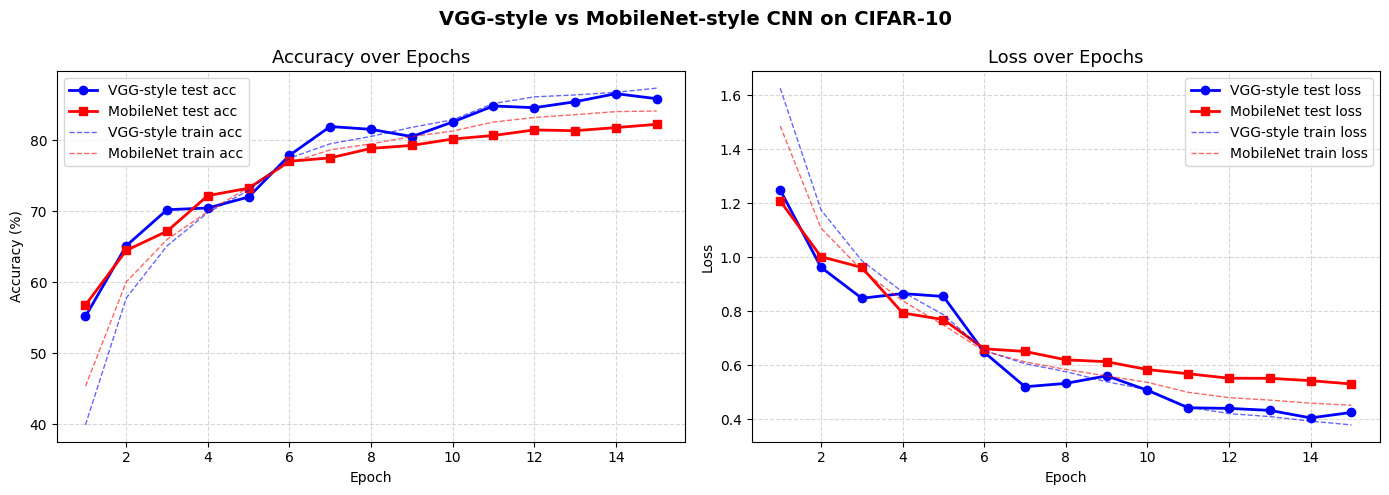

Plot saved as learning_curves.png


In [13]:
epochs = list(range(1, 16))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy plot ---
axes[0].plot(epochs, vgg_test_acc,  'b-o', label='VGG-style test acc',     linewidth=2)
axes[0].plot(epochs, mob_test_acc,  'r-s', label='MobileNet test acc',      linewidth=2)
axes[0].plot(epochs, vgg_train_acc, 'b--', label='VGG-style train acc',     linewidth=1, alpha=0.6)
axes[0].plot(epochs, mob_train_acc, 'r--', label='MobileNet train acc',     linewidth=1, alpha=0.6)
axes[0].set_title('Accuracy over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Loss plot ---
axes[1].plot(epochs, vgg_test_loss,  'b-o', label='VGG-style test loss',    linewidth=2)
axes[1].plot(epochs, mob_test_loss,  'r-s', label='MobileNet test loss',    linewidth=2)
axes[1].plot(epochs, vgg_train_loss, 'b--', label='VGG-style train loss',   linewidth=1, alpha=0.6)
axes[1].plot(epochs, mob_train_loss, 'r--', label='MobileNet train loss',   linewidth=1, alpha=0.6)
axes[1].set_title('Loss over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('VGG-style vs MobileNet-style CNN on CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as learning_curves.png")

**Plot efficiency comparison bar chart**

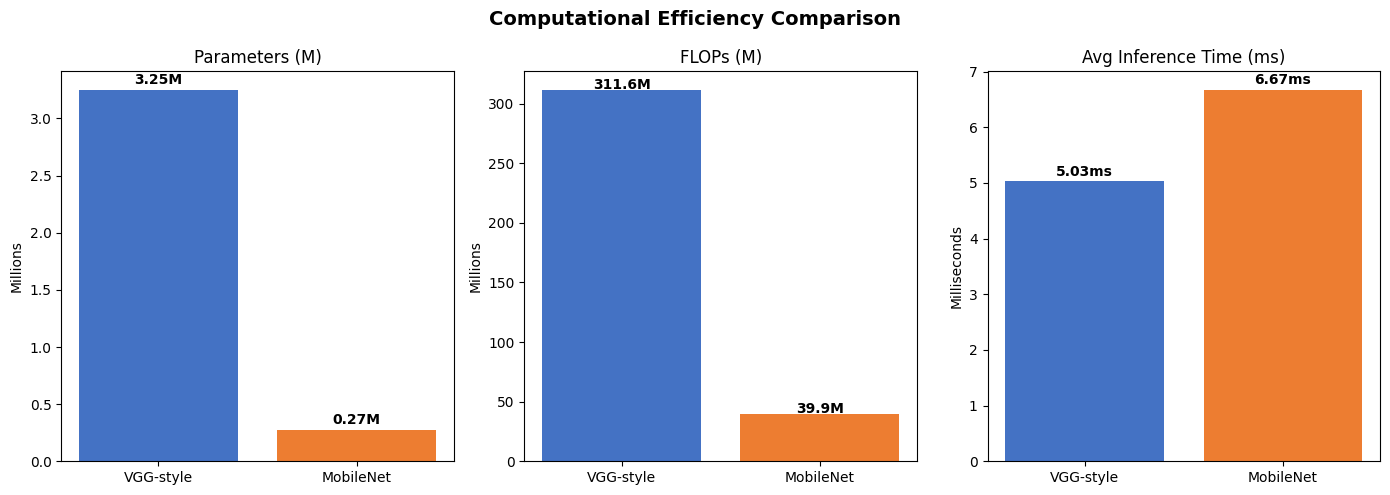

Plot saved as efficiency_comparison.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
models = ['VGG-style', 'MobileNet']
colors = ['#4472C4', '#ED7D31']

# Parameters
axes[0].bar(models, [vgg_params/1e6, mob_params/1e6], color=colors)
axes[0].set_title('Parameters (M)')
axes[0].set_ylabel('Millions')
for i, v in enumerate([vgg_params/1e6, mob_params/1e6]):
    axes[0].text(i, v + 0.05, f'{v:.2f}M', ha='center', fontweight='bold')

# FLOPs
axes[1].bar(models, [vgg_flops/1e6, mob_flops/1e6], color=colors)
axes[1].set_title('FLOPs (M)')
axes[1].set_ylabel('Millions')
for i, v in enumerate([vgg_flops/1e6, mob_flops/1e6]):
    axes[1].text(i, v + 0.5, f'{v:.1f}M', ha='center', fontweight='bold')

# Inference time
axes[2].bar(models, [vgg_inference_ms, mob_inference_ms], color=colors)
axes[2].set_title('Avg Inference Time (ms)')
axes[2].set_ylabel('Milliseconds')
for i, v in enumerate([vgg_inference_ms, mob_inference_ms]):
    axes[2].text(i, v + 0.1, f'{v:.2f}ms', ha='center', fontweight='bold')

plt.suptitle('Computational Efficiency Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('efficiency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as efficiency_comparison.png")

**Save all results to a text file**

In [15]:
with open('results_summary.txt', 'w') as f:
    f.write("CNN ARCHITECTURE EFFICIENCY ANALYSIS — CIFAR-10\n")
    f.write("=" * 55 + "\n\n")

    f.write("COMPARISON TABLE\n")
    f.write("-" * 55 + "\n")
    f.write(f"{'Metric':<30} {'VGG-style':>10} {'MobileNet':>12}\n")
    f.write("-" * 55 + "\n")
    f.write(f"{'Parameters':<30} {vgg_params/1e6:>9.2f}M {mob_params/1e6:>11.2f}M\n")
    f.write(f"{'FLOPs':<30} {vgg_flops/1e6:>9.2f}M {mob_flops/1e6:>11.2f}M\n")
    f.write(f"{'Best test accuracy':<30} {max(vgg_test_acc):>9.2f}% {max(mob_test_acc):>11.2f}%\n")
    f.write(f"{'Final test accuracy':<30} {vgg_test_acc[-1]:>9.2f}% {mob_test_acc[-1]:>11.2f}%\n")
    f.write(f"{'Total training time (s)':<30} {vgg_total_time:>10.1f} {mob_total_time:>12.1f}\n")
    f.write(f"{'Avg inference time (ms)':<30} {vgg_inference_ms:>10.2f} {mob_inference_ms:>12.2f}\n")
    f.write("=" * 55 + "\n\n")

    f.write("EPOCH-BY-EPOCH RESULTS\n\n")
    f.write("VGG-style:\n")
    for i in range(15):
        f.write(f"  Epoch {i+1:>2}: Train Acc={vgg_train_acc[i]:.2f}%  "
                f"Test Acc={vgg_test_acc[i]:.2f}%  "
                f"Train Loss={vgg_train_loss[i]:.4f}  "
                f"Test Loss={vgg_test_loss[i]:.4f}\n")

    f.write("\nMobileNet-style:\n")
    for i in range(15):
        f.write(f"  Epoch {i+1:>2}: Train Acc={mob_train_acc[i]:.2f}%  "
                f"Test Acc={mob_test_acc[i]:.2f}%  "
                f"Train Loss={mob_train_loss[i]:.4f}  "
                f"Test Loss={mob_test_loss[i]:.4f}\n")

print("Results saved to results_summary.txt")

Results saved to results_summary.txt


In [16]:
from google.colab import files
files.download('learning_curves.png')
files.download('efficiency_comparison.png')
files.download('results_summary.txt')
print("All files downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded.
